In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


In [3]:
# ==========================================
# 1. CARICAMENTO DEL MODELLO E IMPOSTAZIONI
# ==========================================
MODEL_PATH = 'rps_custom_model.keras'
NEW_IMAGES_DIR = 'immagini_esempio'  # Nome della cartella principale
IMG_SIZE = (150, 150)                 

if os.path.exists(MODEL_PATH):
    loaded_model = tf.keras.models.load_model(MODEL_PATH)
    print(f"✅ Modello '{MODEL_PATH}' caricato correttamente!")
else:
    raise FileNotFoundError(f"❌ Impossibile trovare il file del modello '{MODEL_PATH}'")

class_labels = ['paper', 'rock', 'scissors']
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

✅ Modello 'rps_custom_model.keras' caricato correttamente!


In [4]:
# ==========================================
# 2. SCANSIONE RICORSIVA (ANCHE NELLE SOTTOCARTELLE)
# ==========================================
img_paths = []

if os.path.exists(NEW_IMAGES_DIR):
    # os.walk esplora la cartella e qualsiasi sotto-cartella al suo interno
    for root, dirs, files in os.walk(NEW_IMAGES_DIR):
        for file in files:
            if file.lower().endswith(valid_extensions):
                img_paths.append(os.path.join(root, file))  # Salvo il percorso completo di ciascuna immagine trovata

Trovate 6 immagini complessive. Elaborazione in corso...

📸 [Sottocartella: immagini_esempio] File: paper_1.jpeg -> Predizione: PAPER (86.99%)


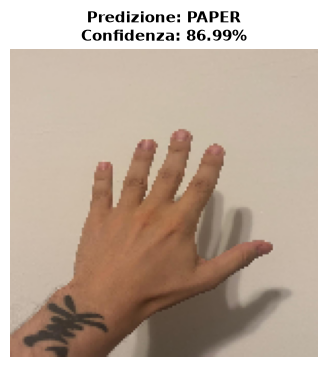

📸 [Sottocartella: immagini_esempio] File: paper_2.jpeg -> Predizione: PAPER (86.11%)


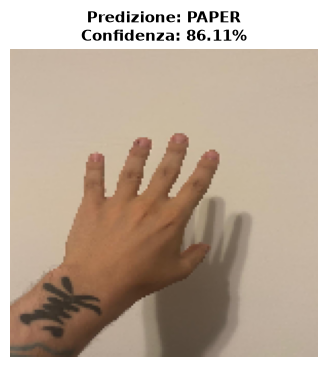

📸 [Sottocartella: immagini_esempio] File: rock_1.jpeg -> Predizione: ROCK (44.85%)


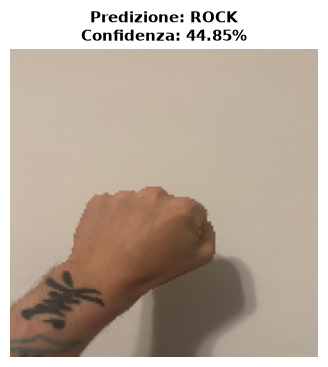

📸 [Sottocartella: immagini_esempio] File: rock_2.jpeg -> Predizione: ROCK (52.14%)


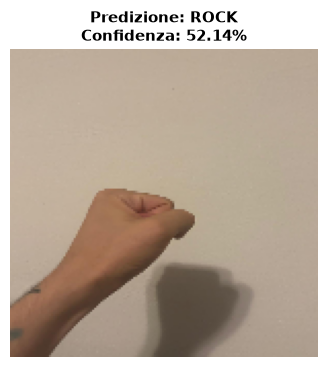

📸 [Sottocartella: immagini_esempio] File: scissor_1.jpeg -> Predizione: SCISSORS (50.33%)


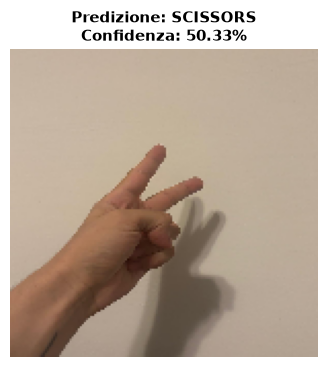

📸 [Sottocartella: immagini_esempio] File: scissor_2.jpeg -> Predizione: SCISSORS (50.62%)


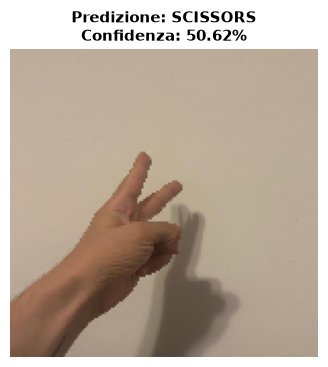

In [5]:
# ==========================================
# 3. PREDIZIONE ED ELABORAZIONE
# ==========================================
if len(img_paths) == 0:
    print(f"Nessuna immagine trovata all'interno di '{NEW_IMAGES_DIR}' o nelle sue sottocartelle.")
else:
    print(f"Trovate {len(img_paths)} immagini complessive. Elaborazione in corso...\n")

    for img_path in img_paths:
        img_name = os.path.basename(img_path)
        subfolder = os.path.basename(os.path.dirname(img_path))
        
        # Caricamento e pre-elaborazione dell'immagine
        img = image.load_img(img_path, target_size=IMG_SIZE)
        img_array = image.img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)

        # Predizione del modello
        predictions = loaded_model.predict(img_batch, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        predicted_label = class_labels[predicted_class_idx]
        confidence = predictions[0][predicted_class_idx] * 100

        print(f"📸 [Sottocartella: {subfolder}] File: {img_name} -> Predizione: {predicted_label.upper()} ({confidence:.2f}%)")

        # Visualizzazione grafica dell'immagine
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Predizione: {predicted_label.upper()}\nConfidenza: {confidence:.2f}%", fontsize=11, fontweight='bold')
        plt.axis('off')
        plt.show()